# Cora 数据集读取与局部图可视化

本部分主要使用 PyTorch Geometric 加载 Cora 数据集，并结合 networkx 对目标节点的局部邻域结构进行可视化。

In [13]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

## 1. 数据集加载

先加载 Cora 数据集，并查看该数据集对应的图数量。

In [14]:
# 加载 Cora 数据集
dataset = Planetoid(root='data/Cora', name='Cora')
len(dataset)

1

In [15]:
dataset.num_classes

7

In [16]:
dataset.num_node_features

1433

## 2. 数据基本信息查看

查看图数据对象的结构，以及训练集、验证集和测试集的划分情况。

In [17]:
# Cora 数据集本质上是一张图
data = dataset[0]
print(data)
data.train_mask.sum().item()

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


140

In [18]:
data.val_mask.sum().item()

500

In [19]:
data.test_mask.sum().item()

1000

## 3. 局部子图提取
选取一个目标节点，并提取其 1-hop 和 2-hop 邻域。使图结构更加清晰

In [20]:
G = to_networkx(data, to_undirected=True)

# 选择一个目标节点，观察其局部邻域结构
target_node = 100

# 提取 1-hop 邻居
neighbors = list(G.neighbors(target_node))
sub_nodes = [target_node] + neighbors
print(len(sub_nodes))

3


In [21]:
# 扩展到2-hop
two_hop = set(sub_nodes)
for n in neighbors:
    two_hop.update(list(G.neighbors(n)))
sub_nodes = list(two_hop)
print(len(sub_nodes))

19


In [22]:
G_sub = G.subgraph(sub_nodes)
# 使用节点标签为子图中的节点着色
node_colors = [data.y[i].item() for i in sub_nodes]
print(node_colors)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]


## 4. 图可视化

最后对提取出的局部子图进行绘制，并对目标节点进行高亮显示。考虑到深色背景环境，这里同时调整边和标题的颜色。

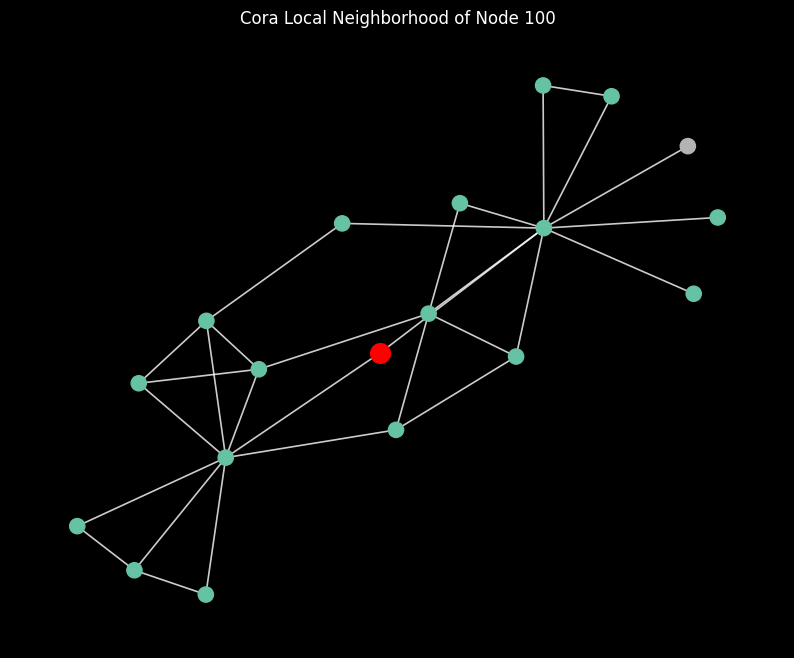

In [23]:

pos = nx.spring_layout(G_sub, seed=42)

# 调整背景和边颜色
plt.figure(figsize=(10, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
nx.draw_networkx_nodes(
    G_sub, pos,
    node_size=120,
    node_color=node_colors,
    cmap=plt.cm.Set2
)
nx.draw_networkx_edges(G_sub, pos, alpha=0.8, edge_color='white', width=1.2)

# 对目标节点进行高亮显示
nx.draw_networkx_nodes(
    G_sub, pos,
    nodelist=[target_node],
    node_color='red',
    node_size=200
)

plt.title(f"Cora Local Neighborhood of Node {target_node}", color='white')
plt.axis("off")
plt.show()